In [1]:
# !pip install \
#   arviz \
#   "altair>=5" \
#   immutabledict \
#   joblib \
#   "natsort>=7.1.1,<8" \
#   "numpy>=2.0.2,<3" \
#   "pandas>=2.2.2,<3" \
#   "scipy>=1.13.1,<2" \
#   "tensorflow>=2.18,<2.19" \
#   "tensorflow-probability>=0.25,<0.26" \
#   "tf-keras>=2.18,<2.19" \
#   xarray


In [2]:
# %restart_python


In [3]:

%load_ext autoreload
%autoreload 2

In [4]:
import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_probability as tfp
import arviz as az
import IPython
import altair as alt
from IPython.display import HTML
import gc

from meridian.mpa.mpa_utils_meridian import MeridianMPAInput

from meridian import constants
from meridian.data import load
from meridian.data import test_utils
from meridian.model import model
from meridian.model import spec
from meridian.model import prior_distribution
from meridian.analysis import optimizer
from meridian.analysis import analyzer
from meridian.analysis import visualizer
from meridian.analysis import summarizer
from meridian.analysis import formatter

# check if GPU is available
from psutil import virtual_memory
ram_gb = virtual_memory().total / 1e9
print('Your runtime has {:.1f} gigabytes of available RAM\n'.format(ram_gb))
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))
print("Num CPUs Available: ", len(tf.config.experimental.list_physical_devices('CPU')))

Your runtime has 25.8 gigabytes of available RAM

Num GPUs Available:  0
Num CPUs Available:  1


In [5]:
home_dir = '/Users/mariappan.subramanian/Library/CloudStorage/OneDrive-TheTradeDesk/MMM/Media Parameter Analysis/tmp'

In [6]:
from client_config import client_config, ec50_multiplier_config, media_parameters_config

In [7]:
main_config =  {
    # "file_path": f"{home_dir}/data/MDF_BY_GEO_Jul8_Channel_events_wit_population.csv",
    "file_path": f"{home_dir}/data/MDF_BY_GEO_EXPANDED_CLIENTS_Aug11.csv",

    # "holiday_file_path": f"{home_dir}/data/holidays_updated_apr21/holiday_effect_",

    "paid_media_imp": ["TV_I", "Display_I", "Video_I"],  # Actual CPM will be calculated based on this
    "paid_media_spends": ["TV_AC", "Display_AC", "Video_AC"],

    "paid_media_viewability_imp": ["TV_VCR", "Display_VCR", "Video_VCR"],  # viewability rate will be calculated based on this
    "paid_media_cols": ["TV_I", "Display_I", "Video_I"],  # not used

    "reach_variables": ["TV_RHH", "Display_RPP", "Video_RPP"],
    "frequency_variables": ["TV_FHH", "Display_FPP", "Video_FPP"],

    "spend_variables_for_cpm_calc": ["TV_AC", "Display_AC", "Video_AC"],  # Prior CPM will be calculated based on this
    "imp_variables_for_cpm_calc": ['TV_I', 'Display_I', 'Video_I'],  # Prior CPM will be calculated based on this

    "response_kpi": "conversions",
    "prior_config": {},
    "prior_type": "spend"
}

Working Spend Plus Informative Transformation Priors

In [8]:
# get prior type for the coefficients (estimates)
prior_type = "cpm_weighted_by_working_spend"
is_national = False
trans_prior_type = 'informative'
tag = "0_test"

print(f"{prior_type=}")
print(f"{is_national=}")
print(f"{trans_prior_type=}")
print(f"{tag=}")

prior_type='cpm_weighted_by_working_spend'
is_national=False
trans_prior_type='informative'
tag='0_test'


In [9]:
client = 'Live_Nation_MasterAdvertiser'

In [10]:
main_config['prior_type'] = prior_type

# ----------------------------- CREATE MODEL INPUT FILE FOR MERIDIAN --------------------------------- #
# create input object
mpa_input = MeridianMPAInput(client=client, client_config=client_config, main_config=main_config)
mdf_mw = mpa_input.mdf_mw.copy()

# write to a temp path for meridian
metrics = [mpa_input.target] + mpa_input.paid_media_imp + mpa_input.paid_media_spends
if is_national:
  # calculate pooled (geo, time level) standard deviation
  pooled_std =(mdf_mw['conversions']/mdf_mw['Population']).std()

  # national level standard deviation
  national_level_conversions = mdf_mw.groupby('WES')[['conversions']].sum().reset_index()['conversions']
  national_level_population = mdf_mw.groupby('WES')[['Population']].sum().reset_index()['Population']
  national_std = (national_level_conversions/national_level_population).std()

  correction_factor = np.round(pooled_std/national_std, 2)
  print(f"Correction factor: {correction_factor}")
  # aggregate out 'geo' field for national models
  mdf = mdf_mw. \
    groupby(['WES'])[metrics].sum(). \
      reset_index(). \
        assign(
          Region='National',
          Population=1.0,
          revenue_per_conversion=1.0
              )
else:
  correction_factor = 1.0
  mdf = mdf_mw[['WES'] + metrics + ['Region', 'Population']]. \
    reset_index(drop=True).assign(revenue_per_conversion= 1.0).copy()
  mdf.loc[:, 'WES'] = pd.to_datetime(mdf['WES']).dt.strftime('%Y-%m-%d')

# write to a temp path (input file path for meridian)
target_file_path = f"{home_dir}/trash/meridian/{client}_national_{is_national}_mdf.csv"
mdf.to_csv(target_file_path, index=False)

# ----------------------------- InputDataLoader --------------------------------- #
coord_to_columns = load.CoordToColumns(
  time='WES',
  geo='Region',
  population='Population',
  kpi='conversions',
  revenue_per_kpi='revenue_per_conversion',
  media=mpa_input.paid_media_imp,
  media_spend=mpa_input.paid_media_spends
)

ordered_chnl_names = [col.split("_")[0] for col in mpa_input.paid_media_imp]
print(f"ordered_chnl_names: {ordered_chnl_names}")
correct_media_to_channel = {col: col.split("_")[0] for col in mpa_input.paid_media_imp}
correct_media_spend_to_channel = {col: col.split("_")[0] for col in mpa_input.paid_media_spends}

# load and format input data
loader = load.CsvDataLoader(
  csv_path=target_file_path,
  kpi_type= 'non_revenue',
  coord_to_columns=coord_to_columns,
  media_to_channel=correct_media_to_channel,
  media_spend_to_channel=correct_media_spend_to_channel,
)
data = loader.load()


cost array: [8153212.008432132, 30750443.094416745, 3369845.9069309193]
cpm array: [0.027543905994543105, 0.003155305260649224, 0.014210290607198901]
viewability percent [0.98827416 0.6258409  0.5746255 ]
working cost array: [0.27557844659380154, 0.6581947173884489, 0.06622683601774958]
prior type is cpm_weighted_by_working_spend and prior values are [2.14655264 0.58730884 0.26613852]
ordered_chnl_names: ['TV', 'Display', 'Video']


In [35]:
# ----------------------------- Define Prior Distribution --------------------------------- #
build_media_channel_args = data.get_paid_media_channels_argument_builder()

# a. beta_m prior (mean for the hierarchical distribution)
media_cf_prior = mpa_input.coeff_prior * correction_factor

if is_national:
  beta_m_prior_sigma = build_media_channel_args(**{chnl:val for chnl, val in zip(ordered_chnl_names, media_cf_prior)})
else:
  # hierarchical model
  allowable_deviation_percent = .1
  geometric_std = np.log(1 + allowable_deviation_percent)
  mu = np.log(0.8 * media_cf_prior) - (geometric_std ** 2 / 2)  # half-normal mean to log-normal mean
  geometric_std = np.full_like(mu, geometric_std)  # log-normal std-dev
  beta_m_prior_mu = build_media_channel_args(**{chnl:val for chnl, val in zip(ordered_chnl_names, mu)})
  beta_m_prior_sigma = build_media_channel_args(**{chnl:val for chnl, val in zip(ordered_chnl_names, geometric_std)})

# a. eta_m prior (std-dev for the hierarchical distribution)
eta_m_mu = 0.0
eta_m_mu_prior = build_media_channel_args(**{chnl:val for chnl, val in zip(ordered_chnl_names, np.repeat(eta_m_mu, len(ordered_chnl_names)))})

allowable_deviation_percent = .1
eta_m_sigma = np.log(1 + allowable_deviation_percent)
eta_m_sigma_prior = build_media_channel_args(**{chnl:val for chnl, val in zip(ordered_chnl_names, np.repeat(eta_m_sigma, len(ordered_chnl_names)))})

# b. Adstock Prior
adstock_lower_bounds = build_media_channel_args(**{chnl:media_parameters_config[chnl]['adstock_range'][0] for chnl in correct_media_to_channel.values()})
adstock_upper_bounds = build_media_channel_args(**{chnl:media_parameters_config[chnl]['adstock_range'][1] for chnl in correct_media_to_channel.values()})

# c. Half saturation Prior
ec50_mu_array = build_media_channel_args(**{chnl:np.round(ec50_multiplier_config[client][chnl], 2) for chnl in correct_media_to_channel.values()})
ec50_scale_array = np.array(ec50_mu_array) * 0.1  # roughly ±90% deviation within 3 standard deviations

# d. Slope Prior
slope_lb = build_media_channel_args(**{chnl:media_parameters_config[chnl]['slope_range'][0] for chnl in correct_media_to_channel.values()})
slope_ub = build_media_channel_args(**{chnl:media_parameters_config[chnl]['slope_range'][1] for chnl in correct_media_to_channel.values()})

# define the prior distribution
if is_national:
  if trans_prior_type == 'informative':
    prior = prior_distribution.PriorDistribution(
        beta_m=tfp.distributions.HalfNormal([float(x) for x in beta_m_prior_sigma], name=constants.BETA_M),
        alpha_m=tfp.distributions.Uniform([float(x) for x in adstock_lower_bounds], [float(x) for x in adstock_upper_bounds], name=constants.ALPHA_M),
        ec_m=tfp.distributions.LogNormal(
          loc=[float(x) for x in ec_m_prior_mu_lnspace], scale=[float(x) for x in ec_m_prior_sigma_lnspace], name=constants.EC_M),
        slope_m=tfp.distributions.Uniform([float(x) for x in slope_lb], [float(x) for x in slope_ub], name=constants.SLOPE_M)
    )
  else:
    prior = prior_distribution.PriorDistribution(
        beta_m=tfp.distributions.HalfNormal([float(x) for x in beta_m_prior_sigma], name=constants.BETA_M))
else:
  if trans_prior_type == 'informative':
    prior = prior_distribution.PriorDistribution(
        beta_m=tfp.distributions.Normal(
                loc=[float(x) for x in beta_m_prior_mu],
                scale=[float(x) for x in beta_m_prior_sigma], name=constants.BETA_M),
        eta_m=tfp.distributions.Normal(
          [float(x) for x in eta_m_mu_prior], [float(x) for x in eta_m_sigma_prior], name=constants.ETA_M),
        alpha_m=tfp.distributions.Uniform([float(x) for x in adstock_lower_bounds], [float(x) for x in adstock_upper_bounds], name=constants.ALPHA_M),
        # ec_m=tfp.distributions.LogNormal(
        #   loc=[float(x) for x in ec_m_prior_mu_lnspace], scale=[float(x) for x in ec_m_prior_sigma_lnspace], name=constants.EC_M),
        ec_m=tfp.distributions.TruncatedNormal(
          loc=[float(x) for x in ec50_mu_array], scale=[float(x) for x in ec50_scale_array],
          low=[float(0.1) for _ in ec50_mu_array], high=[float(x) for x in ec50_mu_array],
          name=constants.EC_M),
        # ec_m=tfp.distributions.HalfNormal([float(x) for x in ec_m_prior_sigma], name=constants.EC_M),
        slope_m=tfp.distributions.Uniform([float(x) for x in slope_lb], [float(x) for x in slope_ub], name=constants.SLOPE_M)
    )
  else:
    prior = prior_distribution.PriorDistribution(
        beta_m=tfp.distributions.Normal(
                loc=[float(x) for x in beta_m_prior_mu],
                scale=[float(x) for x in beta_m_prior_sigma], name=constants.BETA_M)
    )


In [36]:
# prior for hierarhical mean
print(f"{beta_m_prior_mu=}")
print(f"{beta_m_prior_sigma=}")

# prior for hierarhical std
print(f"{eta_m_mu_prior=}")
print(f"{eta_m_sigma_prior=}")

# prior for adstock
print(f"{adstock_lower_bounds=}")
print(f"{adstock_upper_bounds=}")

# prior for half saturation
print(f"{ec50_mu_array=}")
print(f"{ec50_scale_array=}")

# prior for slope
print(f"{slope_lb=}")
print(f"{slope_ub=}")

beta_m_prior_mu=[np.float64(0.5361775642577902), np.float64(-0.7598900230335784), np.float64(-1.5514239280370266)]
beta_m_prior_sigma=[np.float64(0.09531017980432493), np.float64(0.09531017980432493), np.float64(0.09531017980432493)]
eta_m_mu_prior=[np.float64(0.0), np.float64(0.0), np.float64(0.0)]
eta_m_sigma_prior=[np.float64(0.09531017980432493), np.float64(0.09531017980432493), np.float64(0.09531017980432493)]
adstock_lower_bounds=[0, 0, 0]
adstock_upper_bounds=[0.8, 0.45, 0.69]
ec50_mu_array=[np.float64(1.76), np.float64(8.12), np.float64(2.94)]
ec50_scale_array=array([0.176, 0.812, 0.294])
slope_lb=[1.0, 0.5, 1.0]
slope_ub=[2.0, 1.0, 2.0]


In [37]:

# ---------------------------------- Model Run ------------------------------------------- #
FILENAME = f"{tag}_{prior_type}_national_{is_national}_{client}.pkl"
FILEPATH = f"{home_dir}/results/1_MMM_Feasibility/model_objects/{FILENAME}"
# if not os.path.exists(FILEPATH):
model_spec = spec.ModelSpec(prior=prior, media_prior_type='coefficient', media_effects_dist='log_normal')
mmm = model.Meridian(input_data=data, model_spec=model_spec)
mmm.sample_prior(2000)
mmm.sample_posterior(n_chains=2, n_adapt=1000, n_burnin=1000, n_keep=2000)

# finally, save the model
print(f"Saving model to {FILEPATH}")
model.save_mmm(mmm, FILEPATH)

/Users/mariappan.subramanian/Documents/repo/forked/meridian/meridian/model/prior_distribution.py:766: UserWarning: Changing the prior for `slope_m` may lead to convex Hill curves. This may lead to poor MCMC convergence and budget optimization may no longer produce a global optimum.
  warnings.warn(
W0000 00:00:1759193791.685752 6067366 assert_op.cc:38] Ignoring Assert operator mcmc_retry_init/assert_equal_1/Assert/AssertGuard/Assert


Saving model to /Users/mariappan.subramanian/Library/CloudStorage/OneDrive-TheTradeDesk/MMM/Media Parameter Analysis/tmp/results/1_MMM_Feasibility/model_objects/0_test_cpm_weighted_by_working_spend_national_False_Live_Nation_MasterAdvertiser.pkl


In [38]:
model_summary = az.summary(mmm.inference_data.posterior).reset_index()
media_model_summary = model_summary[~(model_summary['index'].str.startswith('mu') | model_summary['index'].str.startswith('knot') | model_summary['index'].str.startswith('tau_g'))]
media_parameters_model_summary = media_model_summary[~(model_summary['index'].str.startswith('beta_') | model_summary['index'].str.startswith('eta_'))]
media_parameters_model_summary

/Users/mariappan.subramanian/Documents/repo/forked/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/mariappan.subramanian/Documents/repo/forked/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4
/var/folders/yc/q3l7zfz56nqcr4r6q26n67rm0000gp/T/ipykernel_73610/2442226161.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  media_parameters_model_summary = media_model_summary[~(model_summary['index'].str.startswith('beta_') | model_summary['index'].str.startswith('eta_'))]


,index,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
0,alpha_m[TV],0.779,0.021,0.741,0.800,0.000,0.000,4028.0,2144.0,1.0
1,alpha_m[Display],0.099,0.070,0.000,0.224,0.001,0.001,4371.0,2284.0,1.0
2,alpha_m[Video],0.611,0.039,0.545,0.686,0.001,0.001,3192.0,1489.0,1.0
96,ec_m[TV],1.675,0.073,1.543,1.760,0.001,0.001,3301.0,1578.0,1.0
97,ec_m[Display],7.095,0.648,5.983,8.116,0.009,0.010,3700.0,1938.0,1.0
98,ec_m[Video],2.861,0.072,2.729,2.940,0.001,0.002,3472.0,1564.0,1.0
258,sigma,0.401,0.006,0.389,0.413,0.000,0.000,4036.0,2986.0,1.0
259,slope_m[TV],1.023,0.024,1.000,1.065,0.000,0.001,4064.0,1969.0,1.0
260,slope_m[Display],0.843,0.085,0.703,1.000,0.002,0.001,2129.0,1835.0,1.0
261,slope_m[Video],1.954,0.044,1.872,2.000,0.001,0.001,4304.0,2152.0,1.0


In [39]:
media_model_summary[(model_summary['index'].str.startswith('beta_m') | model_summary['index'].str.startswith('eta_'))]

/var/folders/yc/q3l7zfz56nqcr4r6q26n67rm0000gp/T/ipykernel_73610/2069341842.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  media_model_summary[(model_summary['index'].str.startswith('beta_m') | model_summary['index'].str.startswith('eta_'))]


,index,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
93,beta_m[TV],0.046,0.081,-0.105,0.193,0.002,0.001,1956.0,2307.0,1.00
94,beta_m[Display],-0.619,0.094,-0.797,-0.444,0.001,0.002,4627.0,2542.0,1.00
95,beta_m[Video],-1.472,0.090,-1.649,-1.307,0.001,0.001,3718.0,3006.0,1.00
99,eta_m[TV],0.037,0.329,-0.422,0.452,0.192,0.024,4.0,56.0,1.42
100,eta_m[Display],0.608,0.050,0.519,0.702,0.001,0.001,1953.0,2738.0,1.00
101,eta_m[Video],0.001,0.659,-0.736,0.734,0.464,0.001,3.0,56.0,1.83


In [40]:
# 3. media effects summary
media_effects_summary = visualizer.MediaSummary(mmm)
media_effects_summary_df = media_effects_summary.summary_table_without_ci(include_prior=False).copy()
media_effects_summary_df

,channel,metric,distribution,impressions,pct_of_impressions,spend,pct_of_spend,cpm,incremental_outcome,pct_of_contribution,roi,effectiveness,mroi,cpik
0,TV,central_tendency,posterior,2.960082e+08,2.879798,8153208.0,19.286797,27.543856,271530272.0,23.829952,33.303532,0.917307,20.153833,0.030196
1,Display,central_tendency,posterior,9.745634e+09,94.813103,30750462.0,72.741661,3.155306,143403888.0,12.585370,4.663476,0.014715,3.122756,0.217734
2,Video,central_tendency,posterior,2.371411e+08,2.307093,3369848.0,7.971534,14.210306,129025696.0,11.323510,38.288326,0.544089,48.702377,0.026236
3,All Channels,central_tendency,posterior,1.027878e+10,100.000000,42273520.0,100.000000,4.112697,543959616.0,47.738819,12.867652,NaN,NaN,0.077915


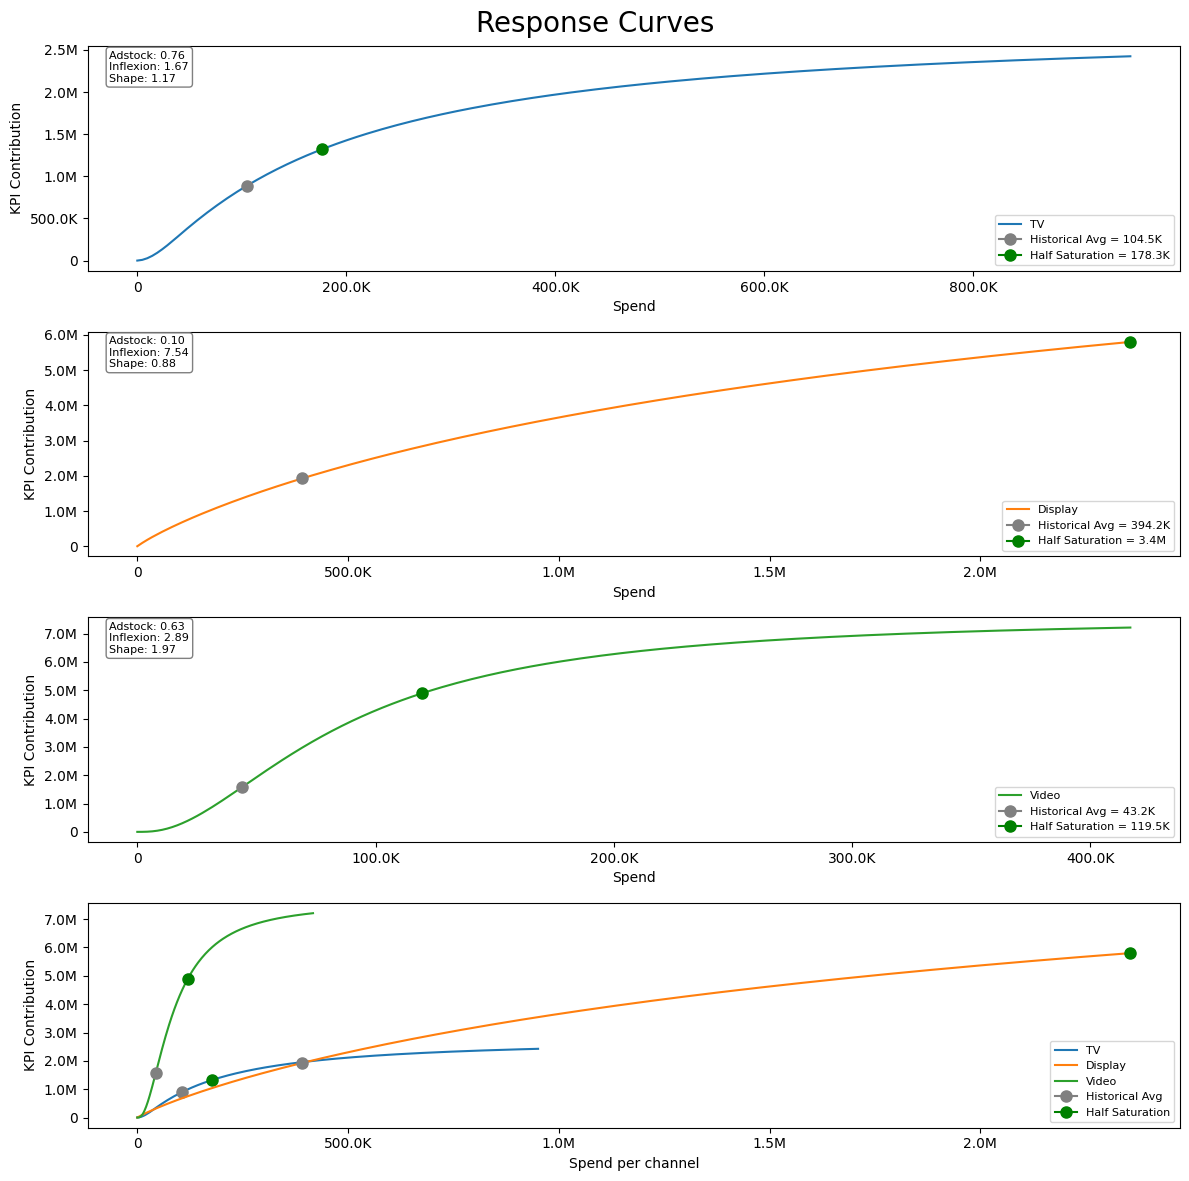

None

In [26]:
# RC Plots
from meridian.analysis.response_curve_generator import ResponseCurveGenerator
# Initialize simulator
simulator = ResponseCurveGenerator(mmm)

# Generate response curves
response_curves, metadata = simulator.generate_response_curves(
  max_multiplier=3.0,
  num_steps=200,
  aggregation_level="national"
)

# Create MPA-style visualization
rc = simulator.plot_response_curves(
  response_curves, metadata,
  figure_size=(12, 12),
  n_columns=1,
  marker_size=8,
  legend_fontsize=8
)
display(rc)

,media_channel,alpha,ec,slope
0,TV,0.758743,1.666474,1.171717
1,Display,0.102672,7.536121,0.883528
2,Video,0.626986,2.894802,1.967103


,media_channel,media_scaled_sum,adstocked_media_sum,saturated_media_sum
0,TV,2676.840820,2579.753662,829.786133
1,Display,2422.896973,2419.403076,328.497437
2,Video,2963.426514,2917.318604,403.346191


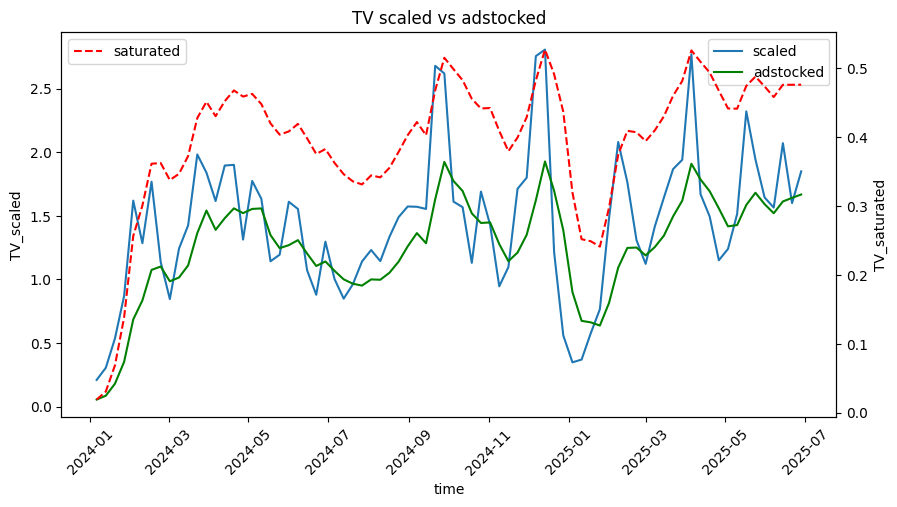

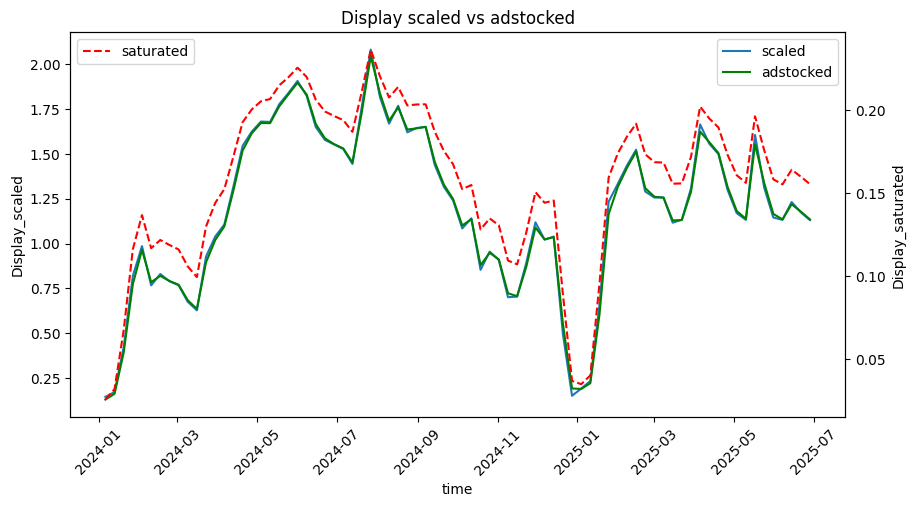

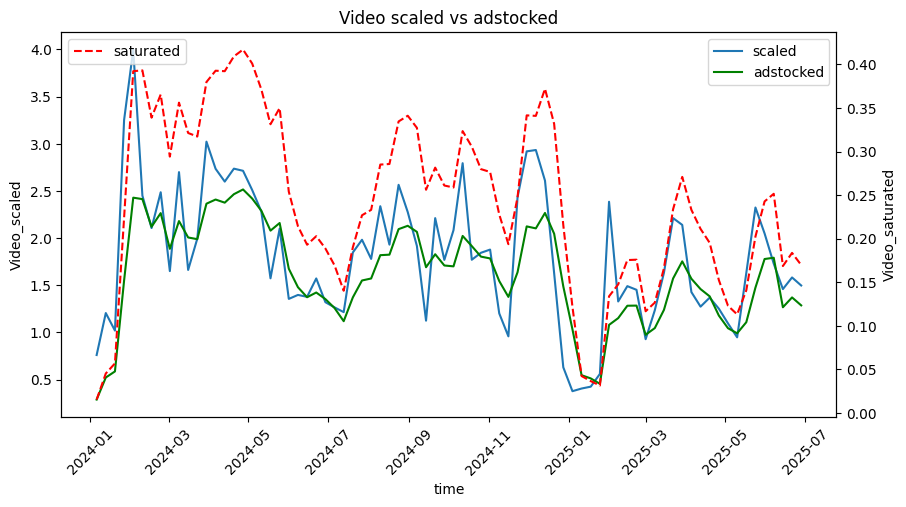

In [27]:
# Media Transformations Plots
from meridian.mpa.plot_media_transformations import ExportMediaTransformations
export_media_transformations = ExportMediaTransformations(mmm)
display(export_media_transformations.media_parameters_df)
display(export_media_transformations.media_sum_to_debug_df)
export_media_transformations.plot_media_journey_all()

In [28]:
model_diagnostics = visualizer.ModelDiagnostics(mmm)
display(model_diagnostics.plot_prior_and_posterior_distribution(parameter='alpha_m'))
display(model_diagnostics.plot_prior_and_posterior_distribution(parameter='ec_m'))
display(model_diagnostics.plot_prior_and_posterior_distribution(parameter='slope_m'))
display(model_diagnostics.plot_prior_and_posterior_distribution(parameter='beta_m'))
display(model_diagnostics.plot_prior_and_posterior_distribution(parameter='eta_m'))


alt.FacetChart(...)

alt.FacetChart(...)

alt.FacetChart(...)

alt.FacetChart(...)

alt.FacetChart(...)